# Pareto sweep analysis

Load a `summary.csv` or `summary.json` from a `pareto_runs/` directory and visualize the Pareto front.

The 3D plot is **interactive** (Plotly): drag to rotate, scroll to zoom, hover for details. Requires `plotly` (`pip install plotly`).

In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point to a completed sweep output directory
RUN_DIR = Path("pareto_runs") / "dale_sanity3_5x5_2026-09-10_14-50-12"

csv_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"

df = pd.read_csv(csv_path)
with json_path.open() as f:
    meta = json.load(f)

print(f"Runs: {len(df)}  |  Pareto points: {df['is_pareto'].sum()}")
print(f"Tasks: {meta['active_tasks']}")
df.head()

Runs: 25  |  Pareto points: 9
Tasks: ['fdgo', 'contextdm1', 'dmsgo']


,run_idx,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,train_time_s,is_pareto
0,1,0.0025,0.00500,0.017474,0.363473,0.020117,0.963542,94.861472,False
1,2,0.0025,0.00875,0.017449,0.369738,0.019054,0.968750,92.905840,False
2,3,0.0025,0.01250,0.017244,0.353215,0.018096,0.963542,93.036041,False
3,4,0.0025,0.01625,0.017872,0.358987,0.017598,0.958333,93.184842,False
4,5,0.0025,0.02000,0.016774,0.351468,0.016938,0.963542,93.364783,True


In [10]:
import plotly.graph_objects as go

pareto = df["is_pareto"].astype(bool)

def hover_text(sub):
    return [
        f"λ_rate={r.lambda_rate:.4g}<br>"
        f"λ_conn={r.lambda_connectivity:.4g}<br>"
        f"task={r.task_loss:.4f}<br>"
        f"meta={r.metabolic_cost:.4f}<br>"
        f"wire={r.wiring_cost:.4f}<br>"
        f"acc={r.mean_acc:.3f}"
        for r in sub.itertuples()
    ]

grid = df.loc[~pareto]
front = df.loc[pareto]

fig = go.Figure()
fig.add_trace(
    go.Scatter3d(
        x=grid["task_loss"],
        y=grid["metabolic_cost"],
        z=grid["wiring_cost"],
        mode="markers",
        name="grid",
        marker=dict(size=5, color="lightgray", opacity=0.85),
        text=hover_text(grid),
        hoverinfo="text",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=front["task_loss"],
        y=front["metabolic_cost"],
        z=front["wiring_cost"],
        mode="markers+text",
        name="Pareto",
        marker=dict(size=8, color="orange"),
        text=[f"({r.lambda_rate:.3g}, {r.lambda_connectivity:.3g})" for r in front.itertuples()],
        textposition="top center",
        textfont=dict(size=10),
        hovertext=hover_text(front),
        hoverinfo="text",
    )
)

fig.update_layout(
    title=f"Pareto front — {meta.get('task_battery', '')} ({len(df)} runs)",
    scene=dict(
        xaxis_title="task loss",
        yaxis_title="firing rate cost",
        zaxis_title="wiring cost",
        aspectmode="cube",
    ),
    width=900,
    height=700,
    legend=dict(x=0.02, y=0.98),
)
fig.show()

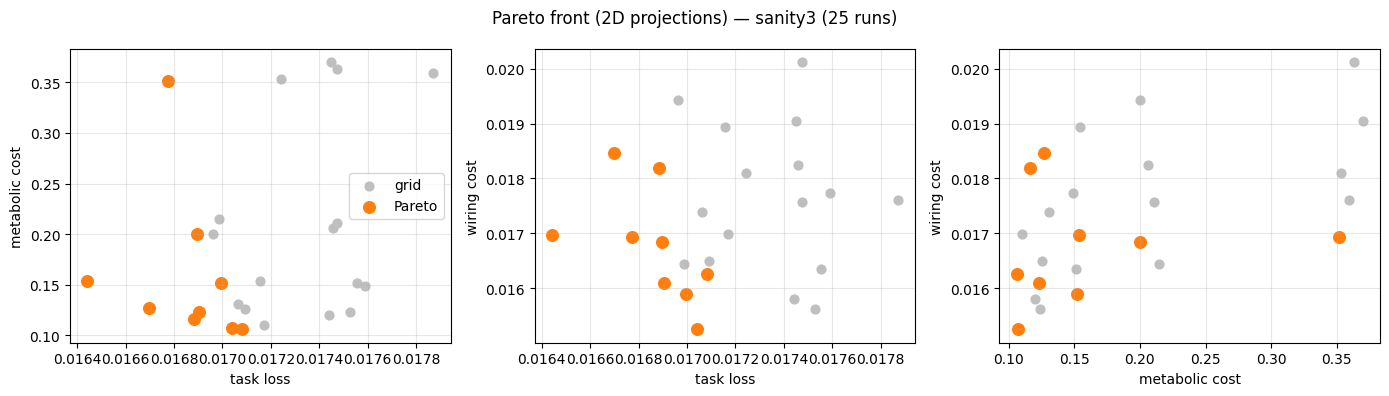

In [11]:
# 2D pair plots (same style as pareto.py pareto_front.png)
pareto = df["is_pareto"].astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ("task_loss", "metabolic_cost", "task loss", "metabolic cost"),
    ("task_loss", "wiring_cost", "task loss", "wiring cost"),
    ("metabolic_cost", "wiring_cost", "metabolic cost", "wiring cost"),
]

for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    ax.scatter(df.loc[~pareto, xc], df.loc[~pareto, yc], c="0.75", s=40, label="grid")
    ax.scatter(df.loc[pareto, xc], df.loc[pareto, yc], c="C1", s=70, label="Pareto")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="best")
fig.suptitle(f"Pareto front (2D projections) — {meta.get('task_battery', '')} ({len(df)} runs)")
fig.tight_layout()
plt.show()

In [12]:
cols = ["lambda_rate", "lambda_connectivity", "task_loss", "metabolic_cost", "wiring_cost", "mean_acc", "is_pareto"]
df.sort_values(["task_loss", "metabolic_cost", "wiring_cost"])[cols]

,lambda_rate,lambda_connectivity,task_loss,metabolic_cost,wiring_cost,mean_acc,is_pareto
12,0.011250,0.01250,0.016442,0.153532,0.016965,0.968750,True
15,0.015625,0.00500,0.016697,0.126941,0.018472,0.973958,True
4,0.002500,0.02000,0.016774,0.351468,0.016938,0.963542,True
20,0.020000,0.00500,0.016882,0.116231,0.018197,0.973958,True
8,0.006875,0.01625,0.016895,0.200391,0.016846,0.968750,True
18,0.015625,0.01625,0.016904,0.122966,0.016087,0.973958,True
5,0.006875,0.00500,0.016962,0.199756,0.019433,0.968750,False
9,0.006875,0.02000,0.016987,0.214789,0.016431,0.963542,False
14,0.011250,0.02000,0.016995,0.152143,0.015895,0.968750,True
24,0.020000,0.02000,0.017040,0.106964,0.015246,0.979167,True
